In [ ]:
# Install dependencies if not already installed in your environment
!pip install cyvcf2 pandas

In [2]:
from cyvcf2 import VCF, Writer
import pandas as pd
import os

def filter_high_moderate(input_vcf_path):
    # Generate output file names dynamically
    base = os.path.splitext(os.path.basename(input_vcf_path))[0]
    output_vcf = f"{base}_Filtered_HighModerate.vcf"
    output_csv = f"{base}_Filtered_HighModerate_summary.csv"

    # Open VCF
    vcf = VCF(input_vcf_path)
    w = Writer(output_vcf, vcf)

    # For summary table
    records = []

    for variant in vcf:
        ann = variant.INFO.get('ANN')
        if ann:
            anns = ann.split(',')
            for a in anns:
                fields = a.split('|')
                if len(fields) > 3:
                    impact = fields[2]
                    if impact in ['HIGH', 'MODERATE']:
                        w.write_record(variant)
                        records.append({
                            'CHROM': variant.CHROM,
                            'POS': variant.POS,
                            'REF': variant.REF,
                            'ALT': ",".join(str(a) for a in variant.ALT),
                            'IMPACT': impact,
                            'EFFECT': fields[1],
                            'GENE': fields[3],
                            'ANN': a
                        })
                        break  # write once per variant if any match

    # Close files
    w.close()
    vcf.close()

    # Write summary table if records exist
    if records:
        df = pd.DataFrame(records)
        df.to_csv(output_csv, index=False, sep='\t')
        print(f"{base}: Filtered variants saved to {output_vcf}")
        print(f"{base}: Summary table saved to {output_csv}")
        return df  # Return dataframe for immediate preview
    else:
        print(f"{base}: No HIGH or MODERATE impact variants found.")
        return pd.DataFrame()  # Return empty dataframe if none found


In [3]:
# Example for first file
input_path = "/home/3V/Downloads/Sample12_Annotated variant.vcf"
df1 = filter_high_moderate(input_path)

[W::vcf_parse] Contig 'chr1' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr10' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr11' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr12' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr13' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr14' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr14_GL000009v2_random' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr14_GL000225v1_random' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'chr14_KI270722v1_random' is not defined in the header. (Quick workaround: index the fi

Sample12_Annotated variant: Filtered variants saved to Sample12_Annotated variant_Filtered_HighModerate.vcf
Sample12_Annotated variant: Summary table saved to Sample12_Annotated variant_Filtered_HighModerate_summary.csv


In [4]:
# View the first few records
df1.head()

,CHROM,POS,REF,ALT,IMPACT,EFFECT,GENE,ANN
0,chr2,95950756,C,A,MODERATE,missense_variant,ANKRD36C,A|missense_variant|MODERATE|ANKRD36C|ENSG00000...
1,chr2,95950758,G,C,MODERATE,missense_variant,ANKRD36C,C|missense_variant|MODERATE|ANKRD36C|ENSG00000...
2,chr2,95950759,C,A,MODERATE,missense_variant,ANKRD36C,A|missense_variant|MODERATE|ANKRD36C|ENSG00000...
3,chr2,95950779,A,C,MODERATE,missense_variant&splice_region_variant,ANKRD36C,C|missense_variant&splice_region_variant|MODER...
4,chr2,95951363,G,A,HIGH,stop_gained,ANKRD36C,A|stop_gained|HIGH|ANKRD36C|ENSG00000174501|tr...


In [5]:
df1.shape

(44, 8)

In [6]:
output_csv_path = "/home/3V/Downloads/variant-filter/filtered12_HighModerate.csv"
df1.to_csv(output_csv_path, sep="\t", index=False)
print(f"Saved filtered results to {output_csv_path}")


Saved filtered results to /home/3V/Downloads/variant-filter/filtered12_HighModerate.csv


## **Combine all filtered output for cohort analysis**

In [7]:
import pandas as pd
import glob

In [8]:
# Path to your variant-filter folder
path = "/home/3V/Downloads/variant-filter/*HighModerate.csv"

In [9]:
# Read all filtered csv files
files = glob.glob(path)
dfs = [pd.read_csv(f, sep="\t") for f in files]

In [10]:
# Combine into one dataframe
combined_df = pd.concat(dfs, ignore_index=True)

In [11]:
# Save combined file
combined_df.to_csv("/home/3V/Downloads/variant-filter/AllSamples_FilteredCombined_updated.csv", sep="\t", index=False)

In [12]:
# Raw Data Confirmation

combined_path = "/home/3V/Downloads/variant-filter/AllSamples_FilteredCombined_updated.csv"
combined_df = pd.read_csv(combined_path, sep="\t")

combined_df.head()


,CHROM,POS,REF,ALT,IMPACT,EFFECT,GENE,ANN
0,chr13,18176171,C,T,HIGH,splice_acceptor_variant&intron_variant,RP11-341D18.2,T|splice_acceptor_variant&intron_variant|HIGH|...
1,chr15,20251534,C,T,HIGH,splice_acceptor_variant&intron_variant,RP11-492D6.3,T|splice_acceptor_variant&intron_variant|HIGH|...
2,chr15,20534501,A,G,MODERATE,missense_variant,GOLGA6L6,G|missense_variant|MODERATE|GOLGA6L6|ENSG00000...
3,chr2,95945173,T,G,MODERATE,missense_variant&splice_region_variant,ANKRD36C,G|missense_variant&splice_region_variant|MODER...
4,chr2,95951363,G,A,HIGH,stop_gained,ANKRD36C,A|stop_gained|HIGH|ANKRD36C|ENSG00000174501|tr...


In [13]:
combined_df.shape

(1490, 8)

In [14]:
# Check for unique genes

unique_genes = combined_df['GENE'].dropna().unique()
print(f"Number of unique genes: {len(unique_genes)}")


Number of unique genes: 707


# **Gene Frequency Summary**

In [15]:
# Group by gene and count occurrences
gene_counts = combined_df['GENE'].value_counts().reset_index()
gene_counts.columns = ['GENE', 'Frequency']

In [16]:

# Display top genes
print(gene_counts.head(10))


       GENE  Frequency
0     MUC3A        471
1  ANKRD36C         69
2    ZNF717         26
3    GPRIN2         16
4     BAGE5         14
5   ANKRD36         12
6    MAP2K3         12
7     MUC16          9
8    FRG1DP          6
9     IGLJ3          6


In [18]:
# Save for record
gene_counts.to_csv("/home/3V/Downloads/variant-filter/Gene_Summary.csv", index=False)

In [19]:
# Gene list only in txt format

gene_counts['GENE'].to_csv('/home/3V/Downloads/variant-filter/Gene_Summary_ListOnly.txt', index=False, header=False)


In [ ]:
# g:profile url
# https://biit.cs.ut.ee/gprofiler/gost?organism=hsapiens&query=MUC3A%0AANKRD36C%0AZNF717%0AGPRIN2%0ABAGE5%0AANKRD36%0AMAP2K3%0AMUC16%0AFRG1DP%0AIGLJ3%0AMUC17%0ATPTE%0ARP11-341D18.2%0AIGHV1OR21-1%0ACU104787.1%0AMUC12%0AMYO3A%0AOR51B6%0ACTD-3088G3.8%0AIL1RL1%0AGAA%0AACAN%0ATTN%0APKD1L3%0ACCDC168%0AIGLV5-48%0ANPIPB15%0AKCNJ12%0AOR11L1%0ASPTBN5%0AFRAS1%0APRSS51%0AOR11G2%0ATNC%0AADGRF2%0AGDPGP1%0AALKBH3%0AGEN1%0APDILT%0AFHAD1%0ACNTNAP4%0APABPC3%0AOR8H2%0ATRIM51%0ASPANXB1%0APGM5P2%0ANOM1%0ACD164L2%0AC17orf80%0AFLG%0AKMT2C%0ADNAH17%0AADAM22%0ACOBL%0ALAMA1%0AZNF804A%0AALPK2%0AOR2M7%0AVWDE%0ARREB1%0AAKAP13%0AARHGEF5%0ATMEM176B%0ADNHD1%0AMUT%0APSD3%0ASLC18A1%0ACDH17%0ASAXO1%0AMROH2B%0AKIAA1161%0AMALRD1%0APSAPL1%0ANRAP%0APNLIPRP3%0AADGRA1%0AOR51Q1%0APPP2R3A%0ASYNE2%0AC11orf16%0AMS4A14%0ANUP210%0AOR8S1%0ANEB%0AVWA3B%0AFAM179A%0AC2orf16%0AEXO1%0AHEATR1%0AOBSCN%0AATP13A5%0ASEMA6C%0ATRAV8-6%0APATJ%0AAPOL4%0ACROCC%0ACLEC1B%0AZNF568%0AZNF30%0APPFIBP1%0ATACC2%0AZNF701%0APZP%0AHRNR%0AKIZ%0APSG7%0AZNF469%0AWASH1%0ARP11-277P12.6%0AOR4K1%0AZNF773%0ASLC7A13%0ATHSD7A%0AUSP17L17%0AUSP17L18%0AOR4N2%0ANOX4%0ASYTL2%0AOR5B3%0AFAT3%0ANARS2%0AUSP35%0ABCO2%0AVPS37C%0AMS4A13%0ACCDC153%0ABMP2%0AOR2AG2%0AOR52J3%0AOR5W2%0ASRRD%0AOR52W1%0AOR4C5%0ASUN5%0AOR4X1%0APEX16%0AQSER1%0AUSH1C%0ANLRP14%0AZNF214%0AOR2D3%0AOR5F1%0ACDON%0ACRTAM%0ACFAP54%0AAVIL%0AHELB%0AMDM1%0AEDA2R%0AA1BG%0ASYT1%0ACHPT1%0ASIRPD%0AMMAB%0AZNF419%0ANOS1%0ARP11-512M8.11%0AHCAR3%0ADNAH10%0ASLC26A10%0AKRT81%0AOR8D1%0AA2ML1%0APATE1%0APUS3%0ABPIFB4%0AADAMTS8%0ARP3-454B23.1%0ADPPA3%0ASTYK1%0AKRT7%0AREP15%0AMANSC4%0AKIAA1551%0ABICD1%0ASIRPB1%0AFAM186A%0AINS%0AIGLV10-54%0AINPP5A%0AMATN2%0ARP1L1%0AUSP17L7%0ACOL18A1%0ARAB11FIP1%0AMIR2052HG%0AARVCF%0ASNX31%0AMCPH1%0AKLHL38%0AHHLA1%0ALRRC6%0AMAF1%0APUM3%0AIGLV4-60%0AZNF705G%0AESYT2%0AITGB2%0AZMIZ2%0AFRMD1%0ADACT2%0AZNF316%0ASCIN%0AFAM188B%0ANME8%0APCNT%0AOR2F2%0AAGFG2%0AFTCD%0AZAN%0APPP1R3A%0ATMEM213%0ASLC37A3%0AUBAP2%0AKIF24%0AMKI67%0ASRGN%0AACTR5%0ANRP1%0AZNF33A%0ABMS1%0ABICC1%0APHYHIPL%0AHK1%0AKRTAP22-1%0ASH2D4B%0ALINC01520%0APLCE1%0AUQCC1%0APSTK%0ACPXM2%0AFAM171A1%0AITIH5%0ASH3BGR%0ARP11-402G3.3%0AFAM205C%0ACD72%0AAL358113.1%0ATRPM3%0APRUNE2%0ARP5-1050E16.2%0ATNFSF15%0AANKRD16%0ADEC1%0AOR1L8%0ANTMT1%0APOMT1%0ASOHLH1%0APITRM1%0AANHX%0ALRCH1%0AAL354828.1%0ABRCA1%0AFCGBP%0ASLFN5%0AGSDMA%0AKRT24%0AKRT13%0ALGALS14%0AFAM187A%0AAC090286.4%0AEME1%0AMTMR4%0AFBXO27%0ANACA2%0ASCN4A%0APECAM1%0ALTBP4%0ALLGL1%0AHYDIN%0ANUDT7%0ARFWD3%0AZNF404%0APSG11%0AADAT1%0AADAMTS18%0APSG8%0APKD1L2%0AMYO15A%0AMTHFSD%0ASLC52A1%0APITPNM3%0AASGR2%0APFAS%0AMPRIP%0APNPLA3%0AAXIN2%0AWDR87%0ASERPINB11%0ATMEM241%0ACCDC178%0ADCC%0ANWD1%0ASERPINB5%0ASERPINB13%0ACD226%0ACD300LD%0AC18orf63%0AOR10H3%0ATMPRSS9%0ACOL5A3%0AZNF57%0AACTL9%0ACPAMD8%0ACENPM%0AANKRD62%0APIEZO2%0ACTD-2521M24.13%0ACOLEC12%0ALRRC25%0ASLC7A9%0AHEXDC%0AWBP2NL%0ACCDC57%0ARPTOR%0ARNF213%0AUSP36%0ASEC14L1%0AACOX1%0AFDXR%0AZNF233%0ACOG4%0AUSPL1%0AKCNK13%0ACTAGE5%0AFSCB%0AABHD12B%0ACD33%0ASYNDIG1L%0APTPN21%0ANRDE2%0AAKAP6%0AEML1%0AHSP90AA1%0ARP11-736N17.11%0AAHNAK2%0ANBEAP1%0AGOLGA6L2%0APNN%0ARP11-104E19.1%0APDPR%0AADPRHL1%0ACOG3%0ABPIFC%0ACDADC1%0ATBC1D4%0AMYO16%0AATP11A%0AOR4L1%0ARABGGTA%0AZIM3%0ATTC5%0AOR6S1%0ASBK2%0ATRAJ24%0ACHMP4A%0AKNL1%0AWDR76%0APATL2%0ACEACAM20%0ASMIM22%0APPL%0AABAT%0AU51561.1%0ARP11-166B2.1%0ASHISA9%0ATMEM159%0ASQRDL%0AZNF229%0AEARS2%0APRKCB%0AASPHD1%0ACDH11%0ASMPD3%0AZSCAN32%0AOR2C1%0ABAIAP3%0ABSPH1%0APGPEP1L%0ACCDC170%0ANTRK3-AS1%0APIH1D1%0AGOLGA6L9%0AC19orf81%0ARCN2%0ACD276%0AIQCH%0ADIS3L%0AAP4E1%0AATP8B4%0AKLK10%0ASYNJ2%0AC5orf22%0AMYB%0AANKRD26P2%0ACCDC86%0AINCENP%0ATSKU%0ATRIM64B%0AANKK1%0APARP4%0ACSNK1A1L%0ACKAP2%0AOR4C12%0ACLN5%0ASLAIN1%0AKDELC1%0AHOMEZ%0ABAGE2%0ADLEC1%0AMINA%0AOR4A16%0AOR52E4%0AAKNAD1%0ACREBZF%0AVIPR2%0ANSMAF%0APNMA6A%0ATCTE1%0AMET%0ASEC31B%0AALKBH1%0ACOG6%0ATRIM5%0AF12%0AHDGFL1%0AMTCH1%0APODXL%0ASYT11%0AFAM25A%0AC11orf40%0ASYNE1%0ACCDC129%0ASFRP4%0AL1TD1%0AIL22RA1%0ASPOCD1%0AMAST2%0ACYP4A22%0ALEXM%0AC8B%0AFGGY%0AKANK4%0AUPK3BL%0ACACHD1%0AIL23R%0ALINC01360%0ALRRIQ3%0ADNASE2B%0ACOL24A1%0ALRRC8C%0AMYOM3%0ACELA3A%0ANBPF3%0APLA2G2D%0ATAS2R38%0AOR6B1%0AWDR86%0AKIAA1456%0AC8orf48%0AGNRH1%0ACA1%0ASLC45A4%0AZNF7%0AMEGF6%0ARNF207%0ADNAJC11%0AMASP2%0AC1orf167%0ACLCNKB%0AWNT16%0ANRCAM%0ASTEAP4%0AEXPH5%0AKLHL26%0ABIRC7%0ANBPF1%0AGUCA2B%0ANBPF10%0AFCRL1%0AITGA8%0AGLDN%0ADMBT1%0AUSP17L11%0ARMDN1%0AFAM91A1%0ARP11-240B13.2%0AKDM4A%0ACYP2J2%0AGBP1%0ACLEC18B%0ACGNL1%0ACSRP2%0ACRACR2B%0AGOLGA6L6%0ACPS1%0ABATF3%0AFAM110C%0APSME4%0ASLC4A3%0AGLYCTK%0AUCHL1%0ASMAD5%0AKLHL31%0ARAB23%0ALRGUK%0ATSPYL5%0ACYP11B1%0ARP11-262H14.3%0ANBPF12%0AOR4A5%0AETV1%0AZNF365%0ASPON2%0AGABRG1%0ARP11-696N14.1%0APOM121L2%0ANPVF%0ASLC13A1%0ATTI2%0AOR5M11%0ASLC6A12%0ASNX19%0AOTOGL%0AOR4K15%0AIGKV1D-17%0AGC%0AKIAA1109%0ACOL9A1%0ALGALS9C%0ARAI1%0ATMEM132C%0ADENND5B%0AWNK1%0ATSPAN9%0ADYRK4%0ANTF3%0AFAM90A1%0AA2MP1%0ACLEC12A%0AKLRC4%0AYBX3%0ADDX47%0APDE3A%0AGYS2%0ARP11-310I24.1%0ATMTC1%0ADDX11%0ATMED5%0AKIAA1324%0ACEP85L%0ATHAP9%0ASPATA18%0ATMEM165%0ACABS1%0AADAMTS3%0ASOWAHB%0ABMP3%0ARASGEF1B%0ADMP1%0AKLHL5%0AHERC5%0AADH4%0AMANBA%0ACCNA2%0ANUDT6%0ATTC29%0ANEIL3%0ACHRNA9%0ATBC1D1%0AGSTM3%0AHTR3D%0ATF%0ADZIP1L%0ATRIM42%0AAADAC%0AMECOM%0ANAALADL2%0AMCF2L2%0AHTR3E%0AZNF518B%0AAP2M1%0AHRG%0ALSG1%0AZNF141%0AZFYVE28%0ATBC1D14%0ACPZ%0AEXOC3%0AZDHHC11B%0AZDHHC11%0AADGRF5%0ASYCP2L%0ASLC17A1%0ASLC26A8%0ADNAH8%0AADCY10P1%0ARP1-139D8.6%0ARPL7L1%0AADGRF4%0ADNAH5%0APKHD1%0ADST%0ALCA5%0ACOQ3%0AASCC3%0AARMC2%0ACCDC162P%0AF13A1%0AHUS1B%0ABTNL8%0AATP10B%0ARP11-492D6.3%0ADAB2%0AC7%0AAGGF1%0AZFYVE16%0AADGRV1%0APJA2%0AEPB41L4A%0AFBN2%0ASLC22A4%0ALECT2%0APCDHAC1%0APCDHB3%0ASLC6A7%0ATHG1L%0AFBXO40%0AMAATS1%0AZNF80%0AOR14I1%0ACR2%0ANSL1%0AUSH2A%0ATLR5%0ATMEM63A%0AOR2G2%0AOR2T27%0ALYPD8%0ACFAP221%0AADI1%0ADRC1%0ACOX7A2L%0AALMS1%0AANKRD36BP2%0AIGKV1D-42%0AGCC2%0APPFIA4%0ALGR6%0AIGFN1%0AF13B%0AC1orf162%0ATSHB%0ANGF%0AANKRD35%0AFLG2%0APGLYRP4%0ASPTA1%0AOR6N1%0AOR10J1%0AC1orf111%0ADUSP27%0ASEC16B%0ACEP350%0ARNASEL%0ALAMC1%0AIL1F10%0ALRP1B%0AZDHHC23%0AFBXW12%0AGLB1%0ASCN5A%0AULK4%0AANO10%0ATOPAZ1%0AEXOSC7%0ASETD2%0ANISCH%0AGALNT3%0AFRMD4B%0AEPHA6%0AOR5AC2%0AMYH15%0AC3orf52%0ABTLA%0ABOC%0AC3orf20%0ATMEM43%0ATATDN2%0ACROCC2%0ATTC21B%0AMYO3B%0AFSIP2%0AC2orf88%0AALS2%0APIKFYVE%0AACADL%0ACOL4A4%0ACOL4A3%0ASP110%0AALPP%0ANGEF%0AMROH2A%0AESPNL%0AGPR35%0ATGIF2LX%0A&ordered=false&all_results=false&no_iea=false&combined=false&measure_underrepresentation=false&domain_scope=annotated&significance_threshold_method=g_SCS&user_threshold=0.05&numeric_namespace=ENTREZGENE_ACC&sources=GO:MF,GO:CC,GO:BP,KEGG,TF,REAC,MIRNA,HPA,CORUM,HP,WP&background=&highlight=true&no_evidences=false
# https://biit.cs.ut.ee/gplink/l/aGqXdN6msRc

 # **Pathway Analysis & Visualisation**

In [20]:
import pandas as pd

# Load the g:Profiler enrichment results
gp = pd.read_csv('/home/3V/Downloads/variant-filter/gProfiler_hsapiens_08-07-2025_18-35-46__intersections.csv')


In [21]:
# Check top rows and columns
print(gp.columns)
gp.head()

Index(['source', 'term_name', 'term_id', 'highlighted', 'adjusted_p_value',
       'negative_log10_of_adjusted_p_value', 'term_size', 'query_size',
       'intersection_size', 'effective_domain_size', 'intersections'],
      dtype='object')


,source,term_name,term_id,highlighted,adjusted_p_value,negative_log10_of_adjusted_p_value,term_size,query_size,intersection_size,effective_domain_size,intersections
0,GO:MF,olfactory receptor activity,GO:0004984,True,7.401102e-08,7.130704,397,590,38,20246,"OR51B6,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1,OR4K1,..."
1,GO:MF,transmembrane signaling receptor activity,GO:0004888,False,1.471539e-04,3.832228,1307,590,71,20246,"OR51B6,IL1RL1,PKD1L3,OR11L1,OR11G2,ADGRA1,OR51..."
2,GO:MF,molecular transducer activity,GO:0060089,False,1.829960e-03,2.737559,2053,590,95,20246,"OR51B6,IL1RL1,PKD1L3,OR11L1,OR11G2,ADGRA1,OR51..."
3,GO:MF,signaling receptor activity,GO:0038023,False,1.829960e-03,2.737559,2053,590,95,20246,"OR51B6,IL1RL1,PKD1L3,OR11L1,OR11G2,ADGRA1,OR51..."
4,GO:MF,G protein-coupled receptor activity,GO:0004930,False,7.880158e-03,2.103465,839,590,47,20246,"OR51B6,OR11L1,OR11G2,ADGRA1,OR51Q1,OR2M7,OR8S1..."


In [22]:
# Ensure p-adj is numeric
gp['adjusted_p_value'] = pd.to_numeric(gp['adjusted_p_value'], errors='coerce')


In [23]:
# Select top 10 significant terms
top10 = gp.sort_values('adjusted_p_value').head(10)
top10

,source,term_name,term_id,highlighted,adjusted_p_value,negative_log10_of_adjusted_p_value,term_size,query_size,intersection_size,effective_domain_size,intersections
26,GO:CC,cell periphery,GO:0071944,True,1.117666e-09,8.951688,6347,603,251,22149,"MUC3A,GPRIN2,MUC16,MUC17,IGHV1OR21-1,MUC12,OR5..."
8,GO:BP,detection of chemical stimulus involved in sen...,GO:0050911,True,4.774189e-08,7.321100,398,570,38,21026,"OR51B6,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1,OR4K1,..."
0,GO:MF,olfactory receptor activity,GO:0004984,True,7.401102e-08,7.130704,397,590,38,20246,"OR51B6,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1,OR4K1,..."
9,GO:BP,detection of chemical stimulus involved in sen...,GO:0050907,False,8.406833e-08,7.075368,444,570,40,21026,"OR51B6,PKD1L3,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1..."
44,REAC,Expression and translocation of olfactory rece...,REAC:R-HSA-9752946,False,8.613676e-08,7.064811,355,334,36,11004,"OR51B6,OR11L1,OR51Q1,OR2M7,OR4K1,OR8H2,OR4N2,O..."
45,REAC,Olfactory Signaling Pathway,REAC:R-HSA-381753,False,1.490405e-07,6.826696,362,334,36,11004,"OR51B6,OR11L1,OR51Q1,OR2M7,OR4K1,OR8H2,OR4N2,O..."
10,GO:BP,detection of stimulus involved in sensory perc...,GO:0050906,False,2.122453e-07,6.673162,518,570,43,21026,"OR51B6,PKD1L3,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1..."
11,GO:BP,detection of chemical stimulus,GO:0009593,False,2.641805e-07,6.578099,481,570,41,21026,"OR51B6,PKD1L3,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1..."
12,GO:BP,sensory perception of smell,GO:0007608,False,3.529232e-07,6.452320,426,570,38,21026,"OR51B6,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1,OR4K1,..."
43,KEGG,Olfactory transduction,KEGG:04740,False,4.196961e-07,6.377065,428,265,38,8484,"OR51B6,OR11L1,OR11G2,OR51Q1,OR2M7,OR8S1,OR4K1,..."


/tmp/ipykernel_23767/3028813834.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='adjusted_p_value', ylabel='term_name'>

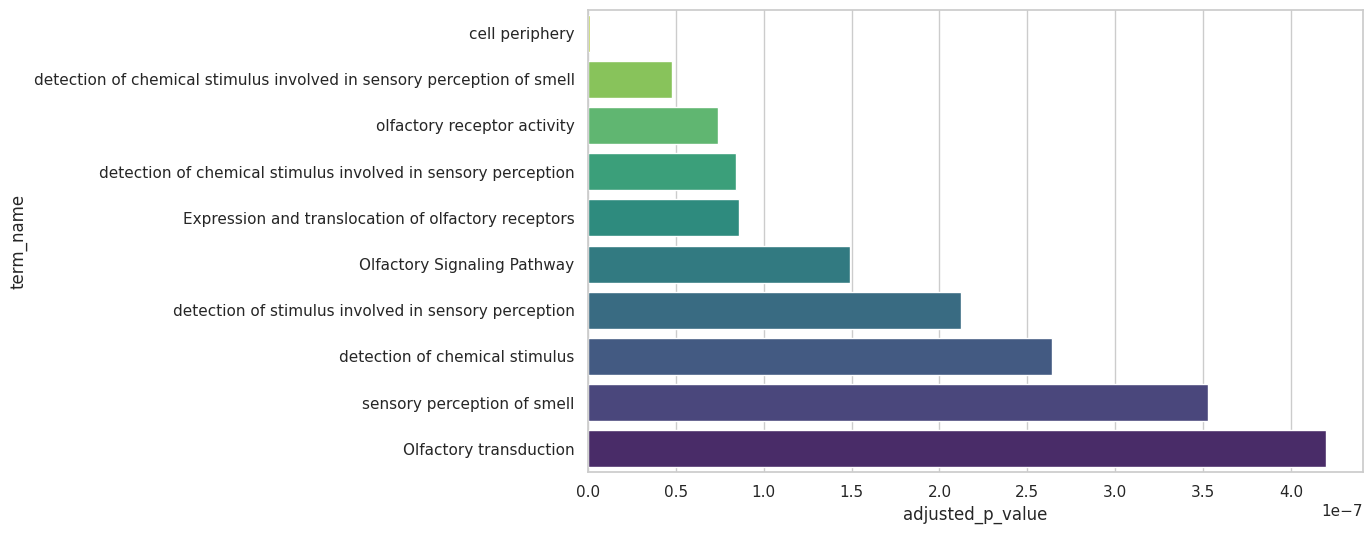

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot aesthetics
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x='adjusted_p_value',
    y='term_name',
    palette='viridis_r'
)


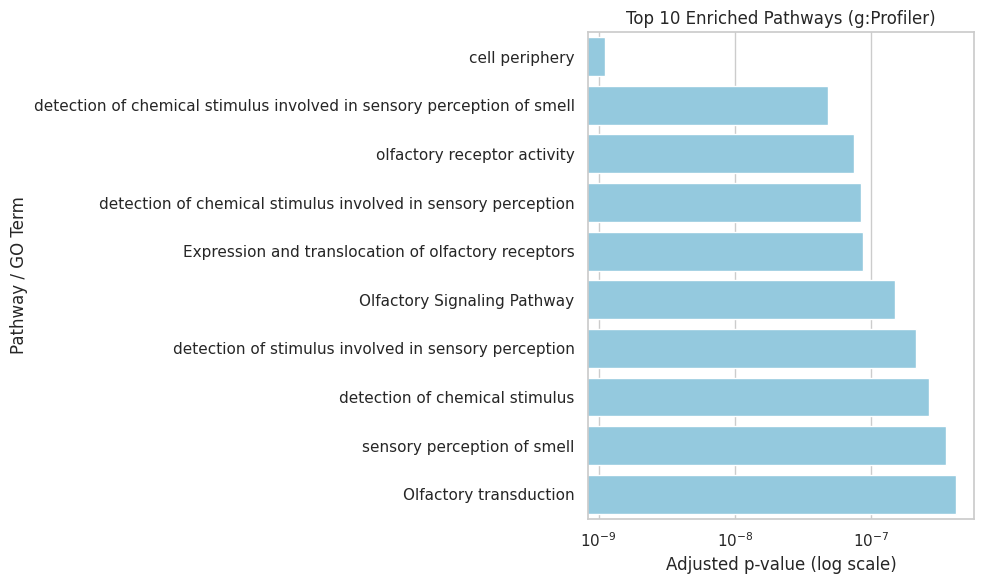

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 pathways by adjusted p-value
top10 = gp.sort_values('adjusted_p_value').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x='adjusted_p_value',
    y='term_name',
    color='skyblue'  # Using fixed color avoids FutureWarnings
)

plt.xscale('log')
plt.xlabel('Adjusted p-value (log scale)')
plt.ylabel('Pathway / GO Term')
plt.title('Top 10 Enriched Pathways (g:Profiler)')
plt.tight_layout()
plt.show()



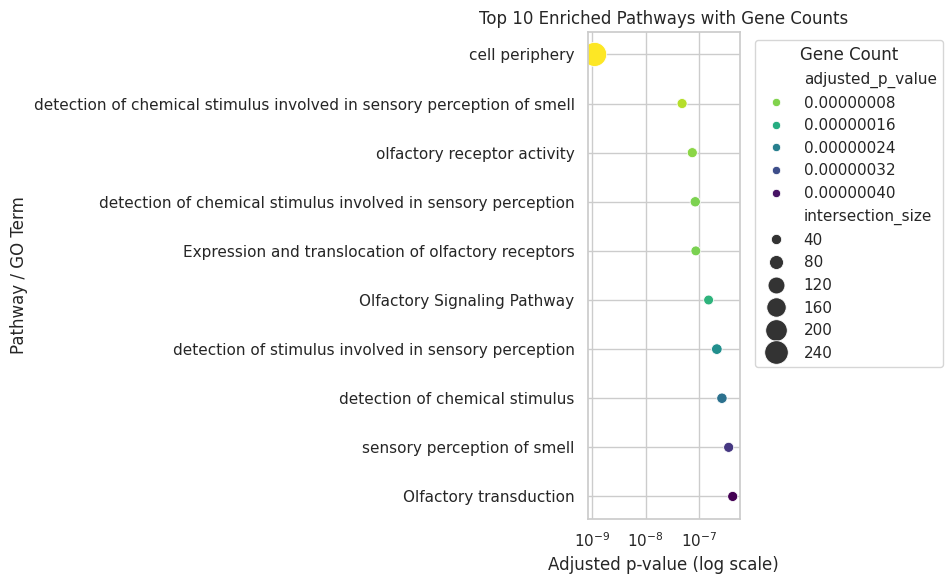

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=top10,
    x='adjusted_p_value',
    y='term_name',
    size='intersection_size',
    hue='adjusted_p_value',
    palette='viridis_r',
    sizes=(50, 300),
    legend='brief'
)

plt.xscale('log')
plt.xlabel('Adjusted p-value (log scale)')
plt.ylabel('Pathway / GO Term')
plt.title('Top 10 Enriched Pathways with Gene Counts')
plt.legend(title='Gene Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [27]:
# Save plots for your thesis/presentation
plt.savefig('/home/3V/Downloads/variant-filter/Top10_Pathways.png', dpi=300)


<Figure size 640x480 with 0 Axes>

# **Group pathways by source**

In [32]:
import pandas as pd

# Load your g:Profiler results
gprofiler_results_path = "/home/3V/Downloads/variant-filter/gProfiler_hsapiens_08-07-2025_18-35-46__intersections.csv"
gprofiler_df = pd.read_csv(gprofiler_results_path)

# Preview the dataset
print(gprofiler_df.head())


  source                                  term_name     term_id  highlighted  \
0  GO:MF                olfactory receptor activity  GO:0004984         True   
1  GO:MF  transmembrane signaling receptor activity  GO:0004888        False   
2  GO:MF              molecular transducer activity  GO:0060089        False   
3  GO:MF                signaling receptor activity  GO:0038023        False   
4  GO:MF        G protein-coupled receptor activity  GO:0004930        False   

   adjusted_p_value  negative_log10_of_adjusted_p_value  term_size  \
0      7.401102e-08                            7.130704        397   
1      1.471539e-04                            3.832228       1307   
2      1.829960e-03                            2.737559       2053   
3      1.829960e-03                            2.737559       2053   
4      7.880158e-03                            2.103465        839   

   query_size  intersection_size  effective_domain_size  \
0         590                 38       

In [36]:
# Group by 'source' to see counts of enriched pathways per category
pathway_groups = gprofiler_df.groupby('source')['term_name'].count().reset_index()
pathway_groups.columns = ['Pathway_Category', 'Number_of_Enriched_Terms']
print(pathway_groups)
print("✅ This gives a summary of how many GO:MF, GO:BP, KEGG, REAC pathways are enriched.")


  Pathway_Category  Number_of_Enriched_Terms
0            GO:BP                        18
1            GO:CC                        17
2            GO:MF                         8
3               HP                         4
4             KEGG                         1
5             REAC                         6
6               TF                         9
✅ This gives a summary of how many GO:MF, GO:BP, KEGG, REAC pathways are enriched.


# **Extract top pathways within each category**

In [37]:
# For example, get top 3 pathways from each category based on adjusted p-value
top_per_category = gprofiler_df.sort_values('adjusted_p_value').groupby('source').head(3)
top_per_category = top_per_category[['source', 'term_name', 'adjusted_p_value']]
print(top_per_category)
print("This table summarises the most significant pathways per biological grouping, ready for thesis reporting.")


   source                                          term_name  adjusted_p_value
26  GO:CC                                     cell periphery      1.117666e-09
8   GO:BP  detection of chemical stimulus involved in sen...      4.774189e-08
0   GO:MF                        olfactory receptor activity      7.401102e-08
9   GO:BP  detection of chemical stimulus involved in sen...      8.406833e-08
44   REAC  Expression and translocation of olfactory rece...      8.613676e-08
45   REAC                        Olfactory Signaling Pathway      1.490405e-07
10  GO:BP  detection of stimulus involved in sensory perc...      2.122453e-07
43   KEGG                             Olfactory transduction      4.196961e-07
27  GO:CC                                    plasma membrane      7.374301e-07
46   REAC                                 Sensory Perception      2.126838e-06
28  GO:CC                                       cytoskeleton      2.270679e-05
1   GO:MF          transmembrane signaling receptor 